# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



# Respuesta:

primero, con descargar entiendo que se refieren a los datos de data/ en el github, dicho esto, el ivm es un indicador de desarrollo que busca medir el nivel de vulnerabilidad de los estudiantes, usando el rsh del estudiante, y eso se toma para todo el establecimiento, para luego promediarlo, van de rango 0 a 100 por lo visto en el excel (tomando , como un punto) y este es el número del registro social hogares

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


In [176]:
#codigo para importar cosas
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy as dcopy
import numpy as np

In [177]:
ruta = os.path.join("data","IVM_Establecimientos_2025-2.xlsx")
print(pd.ExcelFile(ruta).sheet_names)

['Índice', 'Parvularia', '1º Ciclo Básico', '2º Ciclo Básico', 'Media']


In [178]:
parvularia = pd.read_excel(ruta, sheet_name="Parvularia")
pciclo = pd.read_excel(ruta, sheet_name="1º Ciclo Básico")
sciclo = pd.read_excel(ruta, sheet_name="2º Ciclo Básico")   
media = pd.read_excel(ruta, sheet_name="Media")

df_original = {
    "Parvularia": parvularia,
    "1º Ciclo Básico": pciclo,
    "2º Ciclo Básico": sciclo,
    "Media": media
}

"""
display(df["par"].head(10))
display(df["1b"].head(10))
display(df["2b"].head(10))
display(df["media"].head(10))
"""
#se usan diccionarios para poder hacer "limpieza masiva" , ej , usar dropna en todos los dataframes

'\ndisplay(df["par"].head(10))\ndisplay(df["1b"].head(10))\ndisplay(df["2b"].head(10))\ndisplay(df["media"].head(10))\n'

In [179]:
df = dcopy(df_original)

In [180]:
#eliminaremos las columnas de id_rbd que no posean datos, es decir,le haremos un dropna, ademas, veremos si 
# en la columna que posee estudiantes evaluados(N EVALUADOS) sihay valores menores a 20, en cuyo caso, se pondra un NaN 
#posteriormente se pondra el promedio de estudiantes evaluados en ID lugar_comuna buscando mantener informacion "local" en los dataframes
#transformarmos a los alumnos a int, porque, no puedes tener medio alumno / (go / jo) /srry jjk reference 
for dataframes in df.values():
    dataframes.dropna(subset=["ID_RBD"], inplace=True)
    dataframes.dropna(subset=["DS_NOM_ESTABLE"], inplace=True)
    dataframes.loc[dataframes["N EVALUADO"] < 20, "N EVALUADO"] = np.nan
    promedios = dataframes.groupby("ID_COMUNA_ESTABLE")["N EVALUADO"].mean()
    for comuna, promedio in promedios.items():
        dataframes.loc[dataframes["ID_COMUNA_ESTABLE"] == comuna, "N EVALUADO"] = dataframes.loc[dataframes["ID_COMUNA_ESTABLE"] == comuna, "N EVALUADO"].fillna((promedio))
        dataframes["N EVALUADO"] = dataframes["N EVALUADO"].fillna(int(dataframes["N EVALUADO"].mean())) 
        dataframes["N EVALUADO"] = dataframes["N EVALUADO"].astype(int)
        

for dataframes in df.values():
    display(dataframes.head(2))

,ID_RBD,DV_RBD,DS_NOM_ESTABLE,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_PROVINCIA_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,...,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto,IVM Salud,IVM CSE Familiar,IVM Estimulación y Apoyo,IVM Familia,IVM CSE Comunal,IVM Derechos
0,2,7,PARVULARIO LAS ESPIGUITAS,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,75,...,41,18,10,6,24.494117,33.111049,34.732329,71.339647,13.929126,28.934927
1,8,6,COLEGIO INTEGRADO EDUARDO FREI MONTALVA,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,29,...,6,9,8,6,33.627244,44.572505,44.160840,70.761131,13.941963,25.186786


,ID_RBD,DV_RBD,DS_NOM_ESTABLE,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_PROVINCIA_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,...,IVM Alto,IVM Muy Alto,IVM Salud,IVM Discapacidad,IVM Educación,IVM Habitabilidad,IVM Familiar,IVM Participación,IVM CSE Familia,IVM CSE Comunal
0,5,1,JOVINA NARANJO FERNANDEZ,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,106,...,26,32,47.884413,1.332290,14.028935,20.943986,37.199066,3.757660,46.502991,22.175271
1,8,6,COLEGIO INTEGRADO EDUARDO FREI MONTALVA,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,116,...,27,61,46.476438,1.704412,12.357032,21.373001,32.552305,19.197948,55.551860,22.175271


,ID_RBD,DV_RBD,DS_NOM_ESTABLE,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_PROVINCIA_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,IVM Establecimiento,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto
0,5,1,JOVINA NARANJO FERNANDEZ,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,60,33.190073,59,0,0,1
1,8,6,COLEGIO INTEGRADO EDUARDO FREI MONTALVA,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,81,43.372432,53,4,6,18


,ID_RBD,DV_RBD,DS_NOM_ESTABLE,DS_TIPO_DEPENDENCIA,DS_RURALIDAD,ID_REGION_ESTABLE,ID_PROVINCIA_ESTABLE,ID_COMUNA_ESTABLE,DS_COMUNA_ESTABLE,N EVALUADO,IVM Establecimiento,IVM Bajo,IVM Medio,IVM Alto,IVM Muy Alto
0,1,9,LICEO POLITECNICO ARICA,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,674,27.530664,165,40,62,407
1,4,3,LICEO OCTAVIO PALMA PEREZ,Servicio Local de Educación(SLE),Urbano,15,151,15101,Arica,1224,14.893692,979,65,48,132


Personalmente , como Desconozco el uso del dataframe, dejare el dataframe asio, sin embargo, eliminaria datos que no nos sean utiles en el contexto, por ejemplo, a nivel nacional , es decir , buscando el promedio total, las comunas no nos sirven, el tipo de dependiencia, tambien, no se como usarlas, entre otras

In [181]:
#Respuesta a)
for i in df.items():
    print(f"Cantidad de establecimientos en {i[0]}" ,i[1].shape[0])
    


Cantidad de establecimientos en Parvularia 6163
Cantidad de establecimientos en 1º Ciclo Básico 7082
Cantidad de establecimientos en 2º Ciclo Básico 5662
Cantidad de establecimientos en Media 2618


In [182]:
#Respuesta b)
for i in df.items():
    rutaa = os.path.join("data",f"{i[0]}.csv")
    pd.DataFrame.to_csv(i[1], rutaa, index=False)

In [183]:
for i in df.items():
    rutaa = os.path.join("data",f"{i[0]}.csv")
    print(f"el archivo pesa para {i[0]} :" , round(os.path.getsize(rutaa) / 1024**2, 4) , "MB")

el archivo pesa para Parvularia : 1.291 MB
el archivo pesa para 1º Ciclo Básico : 1.6882 MB
el archivo pesa para 2º Ciclo Básico : 0.6376 MB
el archivo pesa para Media : 0.3136 MB


In [184]:
#Respuesta c)
suma = 0
for i in df.values():
    suma += i["N EVALUADO"].sum()

print("El total de estudiantes evaluados en todo el pais es de :" , suma)
    

El total de estudiantes evaluados en todo el pais es de : 2909916


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [185]:
com = os.path.join("data","comunas.shp")
comunas = gpd.read_file(com)


## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


In [186]:
for data in df.items():
    i = data[1] #escribi el codigo con i , esto es para no reescribir ese i a otra cosa
    rural = i[i["DS_RURALIDAD"] == "Rural"].value_counts().sum()
    urbano = i[i["DS_RURALIDAD"] == "Urbano"].value_counts().sum()
    print("--------------------------------------------------")
    print(f"La cantidad de establecimientos rurales en {data[0]} son {rural}")
    print(f"La cantidad de establecimientos urbanos en {data[0]} son {urbano}") 
    print()
    print(f"en el nivel {data[0]} hay {round( rural / (rural + urbano) * 100, 2)} porcentaje de rurales y {round( urbano / (rural + urbano) * 100, 2)} porcentaje de urbanos")
    print()


--------------------------------------------------
La cantidad de establecimientos rurales en Parvularia son 1260
La cantidad de establecimientos urbanos en Parvularia son 4903

en el nivel Parvularia hay 20.44 porcentaje de rurales y 79.56 porcentaje de urbanos

--------------------------------------------------
La cantidad de establecimientos rurales en 1º Ciclo Básico son 2954
La cantidad de establecimientos urbanos en 1º Ciclo Básico son 4128

en el nivel 1º Ciclo Básico hay 41.71 porcentaje de rurales y 58.29 porcentaje de urbanos

--------------------------------------------------
La cantidad de establecimientos rurales en 2º Ciclo Básico son 1492
La cantidad de establecimientos urbanos en 2º Ciclo Básico son 4170

en el nivel 2º Ciclo Básico hay 26.35 porcentaje de rurales y 73.65 porcentaje de urbanos

--------------------------------------------------
La cantidad de establecimientos rurales en Media son 169
La cantidad de establecimientos urbanos en Media son 2449

en el nivel

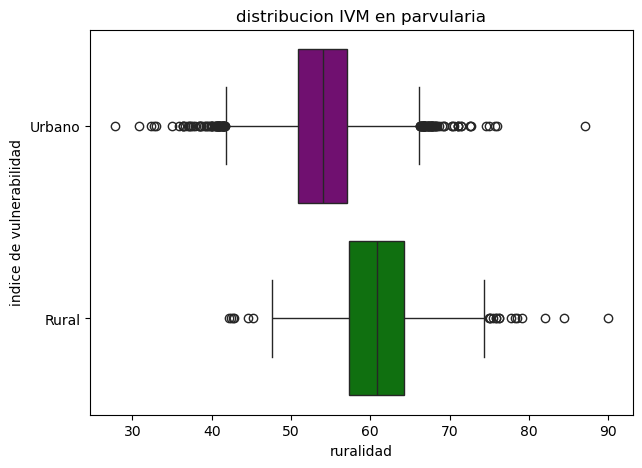

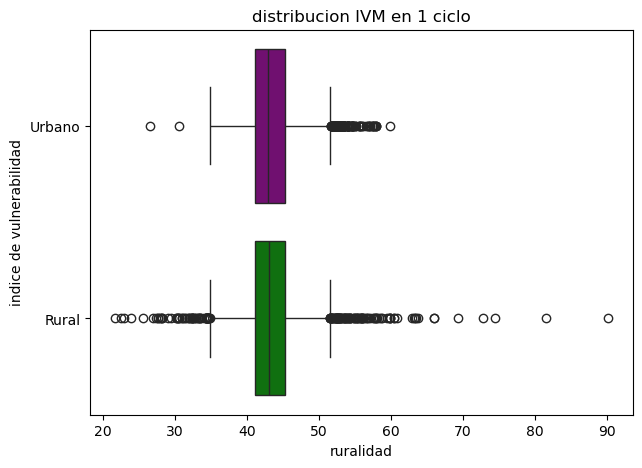

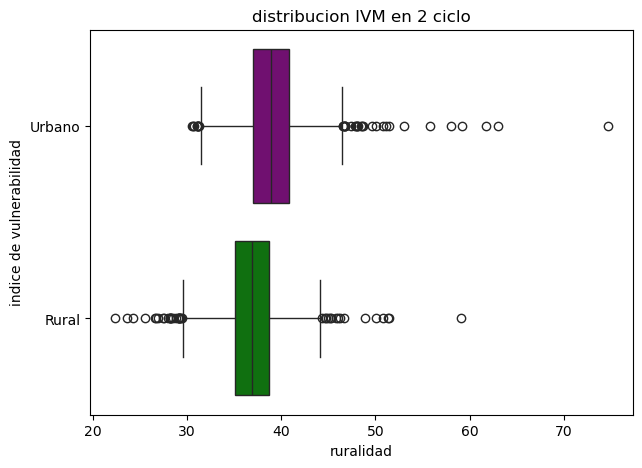

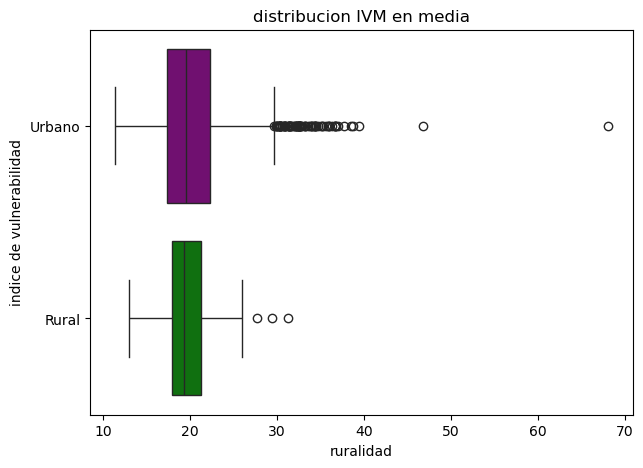

In [187]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df["Parvularia"], x="IVM Establecimiento", y="DS_RURALIDAD", palette=["purple", "green"], hue="DS_RURALIDAD", legend=False)
plt.title("distribucion IVM en parvularia")
plt.xlabel("ruralidad")
plt.ylabel("indice de vulnerabilidad")

plt.figure(figsize=(7, 5))
sns.boxplot(data=df["1º Ciclo Básico"], x="IVM Establecimiento", y="DS_RURALIDAD", palette=["purple", "green"], hue="DS_RURALIDAD", legend=False)
plt.title("distribucion IVM en 1 ciclo")
plt.xlabel("ruralidad")
plt.ylabel("indice de vulnerabilidad")

plt.figure(figsize=(7, 5))
sns.boxplot(data=df["2º Ciclo Básico"], x="IVM Establecimiento", y="DS_RURALIDAD", palette=["purple", "green"], hue="DS_RURALIDAD", legend=False)
plt.title("distribucion IVM en 2 ciclo")
plt.xlabel("ruralidad")
plt.ylabel("indice de vulnerabilidad")

plt.figure(figsize=(7, 5))
sns.boxplot(data=df["Media"], x="IVM Establecimiento", y="DS_RURALIDAD", palette=["purple", "green"], hue="DS_RURALIDAD", legend=False)
plt.title("distribucion IVM en media")
plt.xlabel("ruralidad")
plt.ylabel("indice de vulnerabilidad")

plt.show()


Respuesta y comentarios:

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

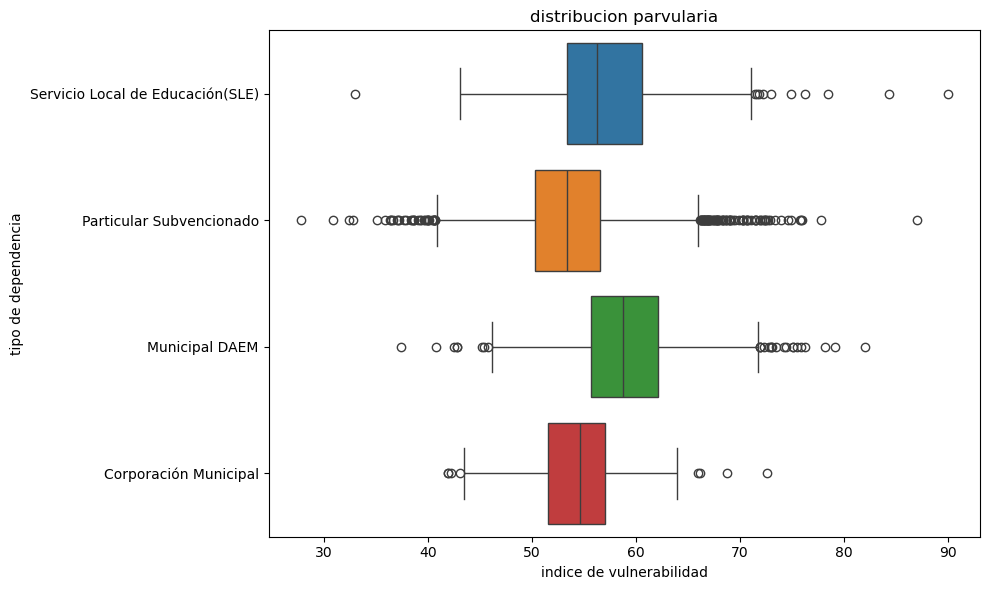

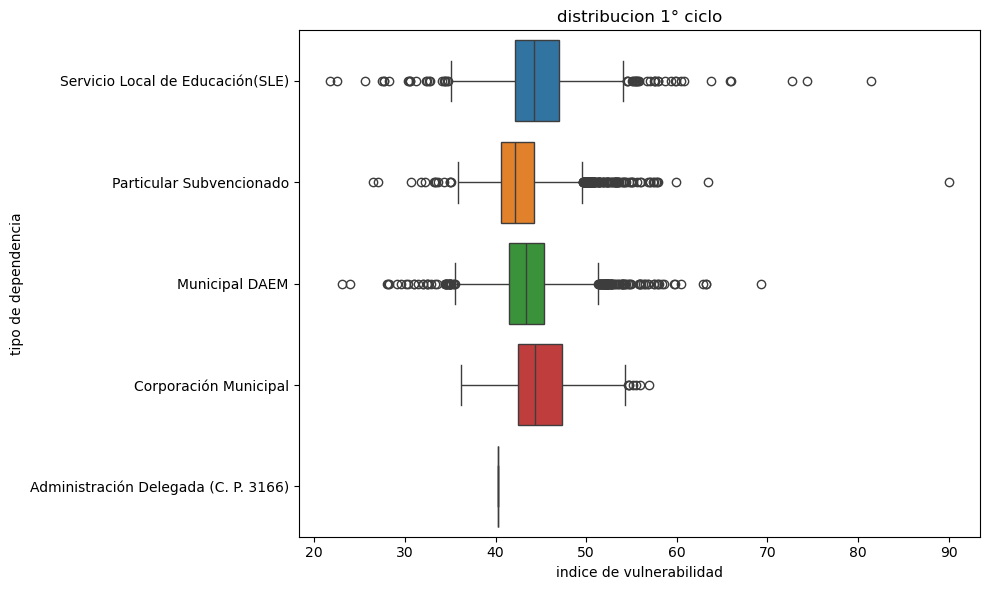

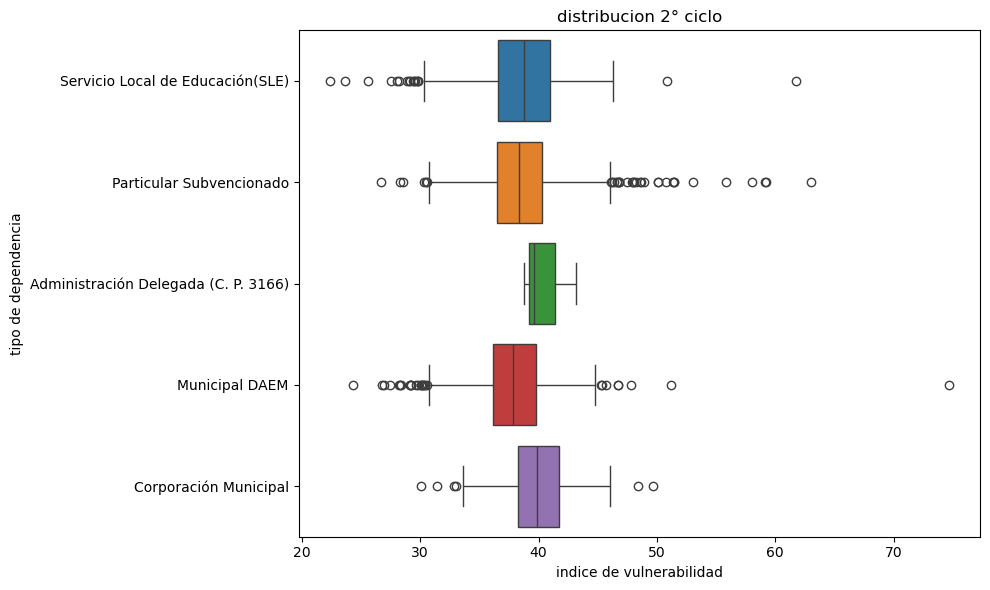

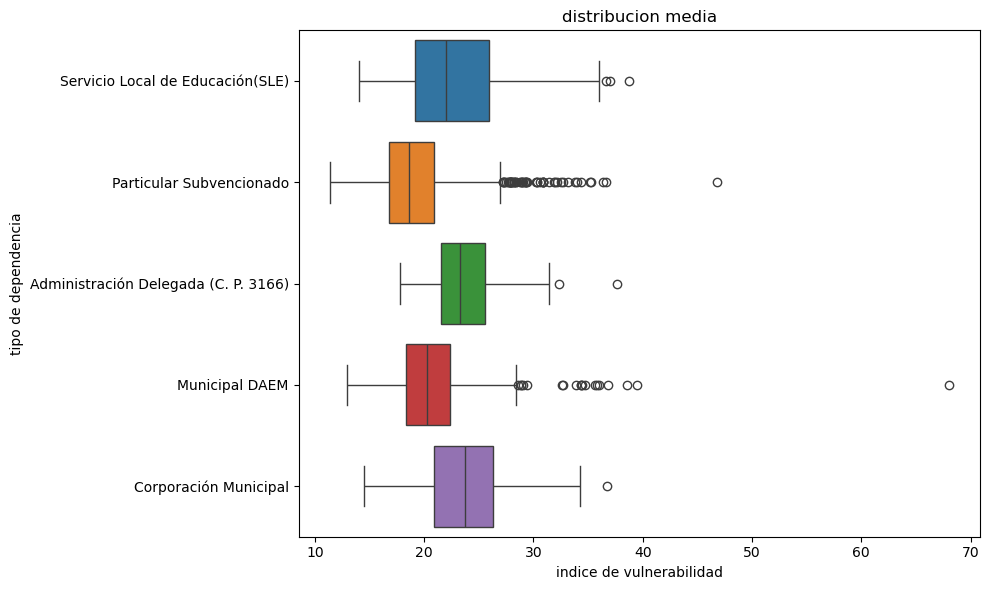

In [188]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df["Parvularia"], x="IVM Establecimiento", y="DS_TIPO_DEPENDENCIA", hue="DS_TIPO_DEPENDENCIA", legend=False)
plt.title("distribucion parvularia")
plt.xlabel("indice de vulnerabilidad")
plt.ylabel("tipo de dependencia")
plt.tight_layout()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df["1º Ciclo Básico"], x="IVM Establecimiento", y="DS_TIPO_DEPENDENCIA", hue="DS_TIPO_DEPENDENCIA", legend=False)
plt.title("distribucion 1° ciclo")
plt.xlabel("indice de vulnerabilidad")
plt.ylabel("tipo de dependencia")
plt.tight_layout()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df["2º Ciclo Básico"], x="IVM Establecimiento", y="DS_TIPO_DEPENDENCIA", hue="DS_TIPO_DEPENDENCIA", legend=False)
plt.title("distribucion 2° ciclo")
plt.xlabel("indice de vulnerabilidad")
plt.ylabel("tipo de dependencia")
plt.tight_layout()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df["Media"], x="IVM Establecimiento", y="DS_TIPO_DEPENDENCIA", hue="DS_TIPO_DEPENDENCIA", legend=False)
plt.title("distribucion media")
plt.xlabel("indice de vulnerabilidad")
plt.ylabel("tipo de dependencia")
plt.tight_layout()

plt.show()


### Respuesta y comentarios:

se puede observar que,como un estandar , se ronda una media similar(con una desviacion de aproximadamente 10 grados de ivm) , y se pueden observar, en forma de los "outlier" como esferas, los datos que se desvian mucho de la media

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

In [189]:
dimenciones  =["IVM Salud", "IVM CSE Familiar", "IVM Estimulación y Apoyo",
    "IVM Familia", "IVM CSE Comunal", "IVM Derechos"]
dimenciones_2 =["IVM Salud", "IVM Discapacidad", "IVM Educación", "IVM Habitabilidad",
    "IVM Familiar", "IVM Participación", "IVM CSE Familia", "IVM CSE Comunal"]
parvularia = (df["Parvularia"])[dimenciones]
basica = (df["1º Ciclo Básico"])[dimenciones_2]
columnas_promedio_parvu = parvularia.mean().sort_values(ascending=False)
columnas_promedio_basica = basica.mean().sort_values(ascending=False)
print("____promedio para parvulario:____")
print(columnas_promedio_parvu)

print("____promedio para basica:____")
print(columnas_promedio_basica)


____promedio para parvulario:____
IVM Familia                 70.667085
IVM CSE Familiar            43.194210
IVM Estimulación y Apoyo    43.095565
IVM Salud                   27.910199
IVM CSE Comunal             18.127686
IVM Derechos                14.211290
dtype: float64
____promedio para basica:____
IVM CSE Familia      54.390762
IVM Salud            43.102350
IVM Familiar         32.196868
IVM CSE Comunal      22.728506
IVM Habitabilidad    20.741263
IVM Educación        13.038839
IVM Discapacidad      5.924766
IVM Participación     5.326800
dtype: float64


In [190]:
max_nombre_parvu = columnas_promedio_parvu.idxmax()
max_valor_parvu = round(columnas_promedio_parvu.max() , 3)

max_nombre_basica = (columnas_promedio_basica.idxmax())
max_valor_basica = round(columnas_promedio_basica.max() , 3)
print(f"el nombre de la dimension con mayor promedio es {max_nombre_parvu} con un valor de {max_valor_parvu} en parvularia")
print(f"el nombre de la dimension con mayor promedio es {max_nombre_basica} con un valor de {max_valor_basica} en basica")

el nombre de la dimension con mayor promedio es IVM Familia con un valor de 70.667 en parvularia
el nombre de la dimension con mayor promedio es IVM CSE Familia con un valor de 54.391 en basica


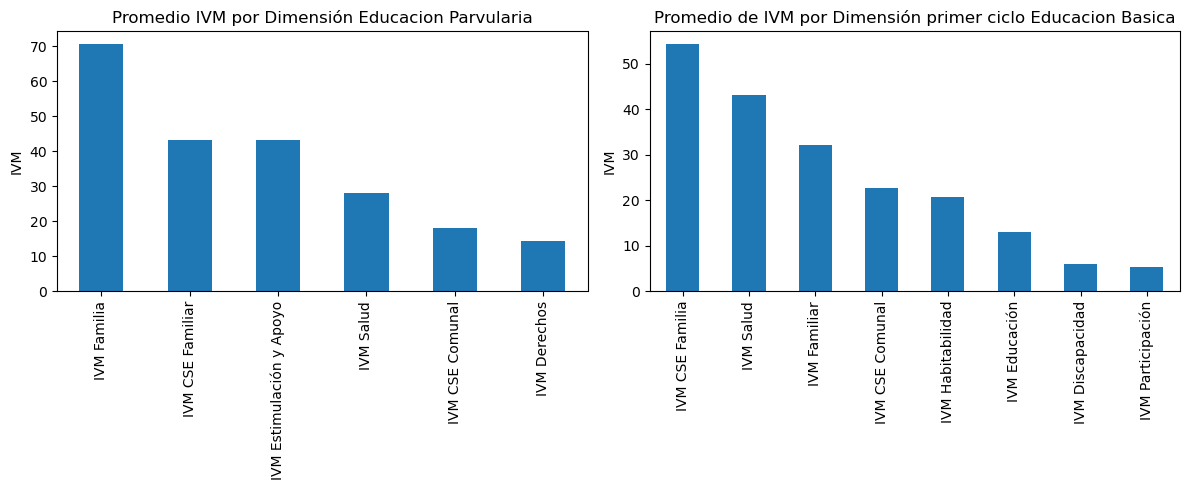

In [191]:
fig , ax = plt.subplots(1, 2, figsize=(12, 5))

columnas_promedio_basica.plot(kind="bar", ax=ax[1], title="Promedio de IVM por Dimensión primer ciclo Educacion Basica")
ax[1].set_ylabel("IVM")
ax[1].tick_params(axis="x")

columnas_promedio_parvu.plot(kind="bar", ax=ax[0], title="Promedio IVM por Dimensión Educacion Parvularia")
ax[0].set_ylabel("IVM")
ax[0].tick_params(axis="x")
plt.tight_layout()
plt.show() 

Como se ve en el grafico se demuestra cuales son los valores mayores y menores, ademas, puesto que los datos provienen de la educacion de estudiantes, en lo que se puede presuponer , contextos similares, podemos ver que los datos poseen una cierta tendencia "similar"

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [198]:
dataframes = []
for niv , data in df.items():
    nombre_col = f"ivm promedio {niv}"
    data[nombre_col] = data.groupby("ID_COMUNA_ESTABLE")["IVM Establecimiento"].transform("mean")
    df_prom = data[["ID_COMUNA_ESTABLE" ,"DS_COMUNA_ESTABLE" , "ID_REGION_ESTABLE", nombre_col]].drop_duplicates(subset=["ID_COMUNA_ESTABLE"]).reset_index(drop=True)
    dataframes.append(df_prom)

ivm_comunal = dataframes[0]
for i in range(1, len(dataframes)):
    df_temp = dataframes[i][["ID_COMUNA_ESTABLE", dataframes[i].columns[-1]]]
    ivm_comunal = ivm_comunal.merge(df_temp, on="ID_COMUNA_ESTABLE", how = "outer")

ivm_comunal.head(5)
    
print("las columnas del nuevo dataframe son :", ivm_comunal.shape[0] , "y en chile hay 346 ")


las columnas del nuevo dataframe son : 345 y en chile hay 346 


Como se puede ver, no corresponde exactamente con las columnas. Esto tiene una explicacion, y es que, en el EDA, se filtraron datos, eliminando columnas con NaN, entre otros. Por lo cual, se debio eliminar una comuna con una baja/nula capacidad de educacion. Esto tambien, en un contexto distinto nos podria haber servido para poder delimitar cuales comunas no cumplen ciertos estandares y, asi, poder hacer un plan de accion para mejorar su educacion en las mismas.

### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [193]:
# respuestas

### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [194]:
# respuestas

## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

In [195]:
# Respuesta

Comentarios y análisis:

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

In [196]:
# respuestas

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:**

In [197]:
# respuesta